# Hands-On AI for Science
### Aug 14 Afternoon: Where Is Waldo? — Convolutional Neural Nets
### Written by Kamila Abdiyeva for CS 440/ECE 448

In this notebook, we'll build a computer vision pipeline from scratch. Similar to the well-known puzzle "Where is Waldo?", we will search for specific patterns within an image. For this simplified version, we will focus on identifying blobs and bars rather than Waldo's canonical red-and-white stripes.

We'll start by implementing the fundamental mathematics of convolution, apply those operations to detect geometric patterns, explore gradient-based edge detection, and finally "train" a filter to recognize patterns automatically using gradient descent.

### INSTRUCTIONS
1) Solutions go in `a14pm_hw1.py`
2) Only edit code inside the marked `TODO` blocks.
3) Do NOT change function names, arguments, or return types.

### Relevance to the real world

Most image, audio, and speech processing algorithms start with a few layers of <a href="https://en.wikipedia.org/wiki/Convolutional_neural_network">convolutional neural networks</a> that are used to extract local patterns in the input signal.  These convolutional layers are followed by several layers of Transformers, that are used to find long-term patterns.

A <a href="https://en.wikipedia.org/wiki/Vision_transformer">vision transformer</a> skips the convolutional layers, and feeds local image patches directly into the Transformer.  Since it chops the image up into patches, though, its behavior is best understood if you first understand convolutional networks.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhasegaw/hands_on_ai_for_science/blob/main/lectures/colab/a14pm_cnn_colab.ipynb)

**No Python installed?** Click the badge above to open a self-contained version of this notebook in Google Colab.  It runs in your browser, with nothing to download and nothing to install.

### Contents

1. [Correlation and Convolution](#convolution)
2. [Kernels for the detection of blobs and stripes](#blobs)
3. [Learning kernels for object detection](#learning)
   

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, Union

import numpy as np

import a14pm_hw1
import a14pm_getdata

import importlib
importlib.reload(a14pm_hw1)
importlib.reload(a14pm_getdata)

<module 'a14pm_getdata' from '/Users/jhasegaw/Dropbox/mark/teaching/minicourse/2026/aug/hands_on_ai_for_science/lectures/a14pm_getdata.py'>

<a id="convolution"></a>


# 1. Fundamentals: Correlation vs. Convolution



* Correlation

**Correlation** is a technique used to find pieces of one signal (the "image," $f[n]$) that match the pattern defined by another signal (the "kernel", $g[n]$).  This is done by shifting the kernel along the image, one pixel at a time; at each location, the output, $y[n]$, is the dot product of the image times the shifted kernel:

$$y[n]=\sum_m f[m] g[m+n]$$

**Convolution** is the same thing as correlation, but with the kernel flipped left-to-right and top-to-bottom first.  One reason for this flipping is that it makes the equations symmetric: You can flip-and-shift the kernel, or you can flip-and-shift the image, and the result is the same.

$$y[n] = \sum_m f[m] g[n-m] = \sum_m f[n-m] g[m]$$

The difference between correlation and convolution is very well described by this wikipedia image from the page on <a href="https://en.wikipedia.org/wiki/Convolution">convolution</a>.  Under each of the headings "Convolution," "Cross-correlation," "Autocorrelation", this image shows the following things:

* The image signal $f[n]$ is high-valued in the middle, and low-valued outside.  If this were an image, the middle part would be white, the outer parts would be black.
* The kernel signal $g[n]$ is a triangle.  If this were an image, it would be a gradient from white to black.
* The convolution or cross-correlation.
* The five line drawings below the convolution show the overlap of $f[n]$ with a shifted $g[n]$.  The product of the two signals is shaded.  The gray arrow, pointing upward, shows the point on $y[n]$ that is computed by adding up all of the shaded portion.
* The next two lines show that convolve(f,g)=convolve(g,f), but correlate(f,g)!=correlate(g,f)

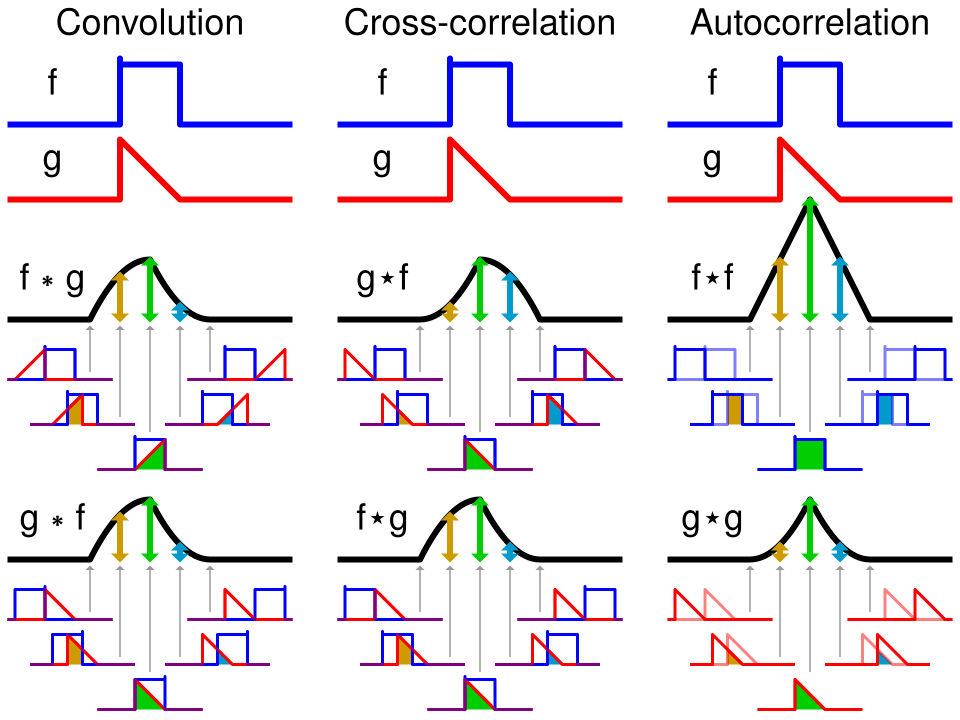

Some people like seeing a video of convolution.  If you would like to see a video:

* <a href="https://commons.wikimedia.org/wiki/File:Convolution_of_box_signals.gif">Here is a video of one-dimensional convolution</a>
* <a href="https://commons.wikimedia.org/wiki/File:Convolution_arithmetic_-_No_padding_no_strides.gif">Here is a video of two-dimensional convolution (an image in two dimensions, and a 2d kernel), with no padding and no strides.  This is the kind of convolution we will implement in this lecture.

### Functions in `a14pm_hw1.py`

`correlation2d(image, kernel)`

* Implement 2D cross-correlation:

  * Slide the kernel across the image.

  * Multiply overlapping values and sum them.

`convolve2d(image, kernel)`

Implement 2D convolution.

  * Mathematically: You must flip the kernel 180 degrees (both horizontally and vertically) before performing the sliding sum.

  * Tip: You can implement this by flipping the kernel and then calling your correlation2d function.



**TODO**: Implement `convolve2d, correlation2d` in `submitted.py`

In [3]:
importlib.reload(a14pm_hw1)

from a14pm_hw1 import convolve2d, correlation2d
import numpy as np

# Define a simple 3x3 input image
input_image = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Define a simple 2x2 asymmetric kernel
# Using an asymmetric kernel ensures convolution (flipped) and correlation are different
kernel = np.array([
    [1, 0],
    [0, -1]
])

print("Input Image:\n", input_image)
print("Kernel:\n", kernel)

# Perform cross-correlation
corr_output = correlation2d(input_image, kernel)
print("\nCross-Correlation Output:\n", corr_output)

# Perform convolution
conv_output = convolve2d(input_image, kernel)
print("\nConvolution Output:\n", conv_output)

# Verify that the outputs are different
if not np.allclose(corr_output, conv_output):
    print("\nSUCCESS: Convolution and Cross-Correlation produced different results for an asymmetric kernel.")
else:
    print("\nWARNING: Convolution and Cross-Correlation produced the same results!")

Input Image:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Kernel:
 [[ 1  0]
 [ 0 -1]]

Cross-Correlation Output:
 [[-4. -4.]
 [-4. -4.]]

Convolution Output:
 [[4. 4.]
 [4. 4.]]

SUCCESS: Convolution and Cross-Correlation produced different results for an asymmetric kernel.


<a id="blobs"></a>

# 2. Synthetic Pattern Detection

Computers "see" features by scanning for regions with high mathematical response to specific kernels.

The wikipedia page on <a href="https://en.wikipedia.org/wiki/Object_detection">object detection</a> has some good explanatory images.  Basically, if we want to recognize an object, we need to create a kernel that has a pattern of pixels similar to the object we're looking for.  Correlation or convolution of the kernel with an image will result in a high output value at the position where a match is found.

 You will implement detectors for two geometric shapes: Blobs and Bars.

## Functions in `a14pm_hw1.py`

`detect_positions(image, kernel)`

This one is written for you.  It convolves the image with the kernel, and then uses <a href="https://numpy.org/doc/stable/reference/generated/numpy.argmax.html">numpy.argmax</a> to find the row and column with the best match.

`detect_blob(image, k=5)`

* Construct a circular kernel of size $k \times k$ (where $k$ is odd). You can assume that circle radius = k//2.

* The kernel should be a binary circle mask (1.0 inside, 0.0 outside) normalized so that the sum of all weights equals 1.0.

* Perform convolution and return the kernel and the coordinates of the global maxima.

`detect_bar(image, k=7)`

* Construct a vertical bar kernel of size $k \times k$.

* The kernel should be all zeros except for a vertical line of ones in the center column, normalized to sum to 1.0.

* Return the kernel and the detected positions of the global maxima.


In [ ]:
importlib.reload(a14pm_hw1)
importlib.reload(a14pm_getdata)

import numpy as np
import matplotlib.pyplot as plt

from a14pm_hw1 import convolve2d, detect_blob, detect_bar, detect_positions
from a14pm_getdata import generate_synthetic_data, qualitative_check

# 1. Generate Data
img, gt = generate_synthetic_data(num_shapes=2)

# 2. Run Detectors
# blob_k = detect_blob()
# bar_k = detect_bar()

# Example visualization
plt.figure(figsize=(15, 3))
plt.subplot(151)
plt.title("Synthetic Image")
plt.imshow(img, cmap='gray')

# Initialize blob_pos and bar_pos to empty arrays or None
# to handle cases where detection fails or isn't implemented
blob_pos = np.array([])
bar_pos = np.array([])

# Detect Blobs
blob_k, blob_pos = detect_blob(img)
blob_map = convolve2d(img, blob_k)
plt.subplot(152)
plt.title("Blob Detections")
plt.imshow(blob_map, cmap='hot')
plt.plot(blob_pos[:, 1], blob_pos[:, 0], 'cx')

# Detect Bars
bar_k, bar_pos = detect_bar(img)
bar_map = convolve2d(img, bar_k)

plt.subplot(153)
plt.title("Bar Detections")
plt.imshow(bar_map, cmap='hot')
plt.plot(bar_pos[:, 1], bar_pos[:, 0], 'cx')

plt.subplot(154)
plt.title("Blob Kernel")
plt.imshow(blob_k, cmap='gray')

plt.subplot(155)
plt.title("Bar Kernel")
plt.imshow(bar_k, cmap='gray')


<a id="learning"></a>

# 3. Learning Kernels for Object Detection

In the previous section, you manually engineered kernels to detect blobs and bars. This process is known as feature engineering and was the standard in computer vision for decades.

Modern AI doesn't rely on human-designed filters. Instead, kernels are "learned" from data. You will implement a simplified training loop to find a $3 \times 3$ kernel that can distinguish a Blob (Label 1) from a Bar (Label 0).

`train_classifier(images, labels, epochs=100)`

Optimize a $3 \times 3$ kernel $g[m_1,m_2]$ using Stochastic Gradient Descent (SGD). SGD is an optimization algorithm that iteratively updates model parameters (weights) by calculating the gradient of the loss function for **a single training example** at a time:

* Initialize: Start with a 3x3 kernel of small random values.

* Forward Pass: Convolve the image (using `convolve2d`) and use `get_positions` to find the position of the peak response ($[n_1^*,n_2^*]$) and the value of the peak response ($max$).

* Loss: Use Mean Squared Error (MSE): $L = (max - tgt)^2$, where $tgt$ is the desired output:

  $tgt = 1.0$ if the image contains a blob.

  $tgt = 0.0$ if the image contains a bar.

* Backprop: Calculate the gradient of the loss with respect to the kernel weights, which should be the image flipped and shifted by the max coordinate, $f[n_1^*-m_1,n_2^*-m_2]$, scaled by the error $2(max-tgt)$.

* Update: $g[m_1,m_2] = g[m_1,m_2] - (lr \times gradient)$

* Adjust hyperparameter $lr$ (learning rate) to achieve the best performance.

  Learning Rate ($lr$): A hyperparameter that controls how much to change the model in response to the estimated error each time the model weights are updated.

  If $lr$ is too small, training will take a very long time to converge.

  If $lr$ is too large, it may cause the weights to oscillate wildly or even diverge.

* Dataset Setup: Use the provided synthetic generator in `a14pm_getdata.py` to create a balanced set of blob and bar images.

`predict(image, kernel, threshold=0.5):`

*   perform convolution with learned kernel using `convolve2d`
*   find the global maxima using `detect_positions`
*   return  global maxima > threshold, global maxima



### To think about

 - Interpretability: After training, what does your learned kernel look like? Does it resemble the manual blob/bar kernels you designed in Q2?



Generating dataset...


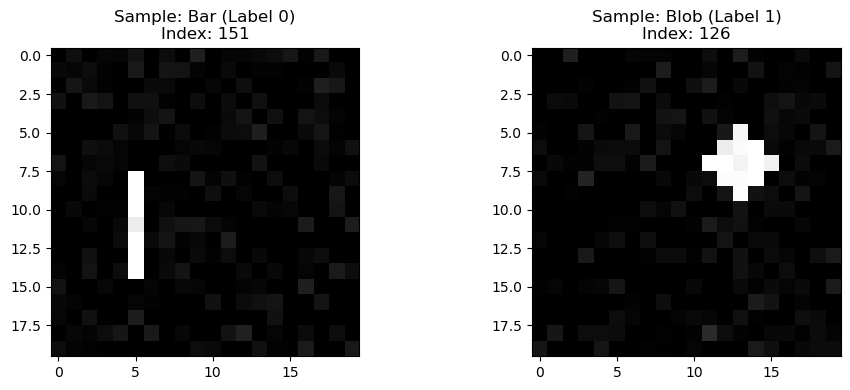

Training...

Final Test Accuracy: 57.50%


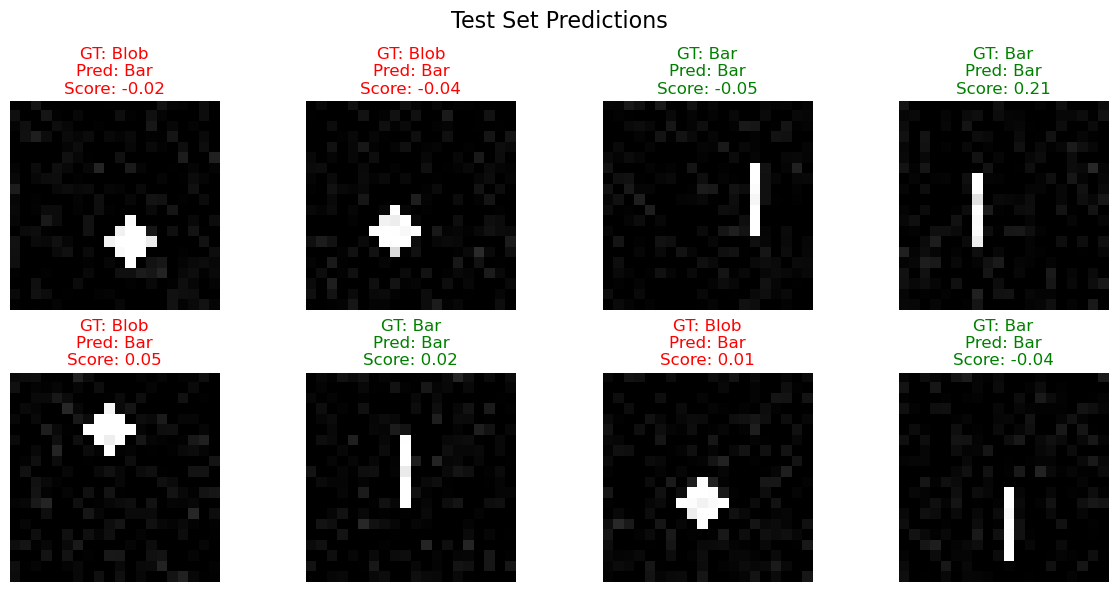

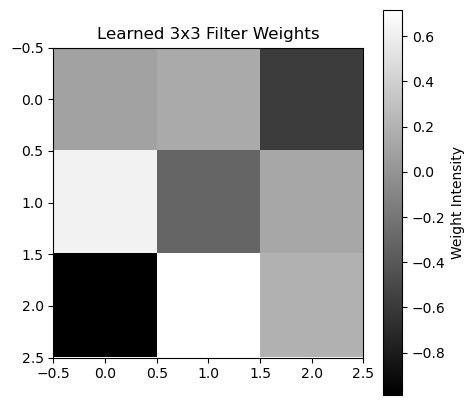

In [22]:
importlib.reload(a14pm_hw1)
importlib.reload(a14pm_getdata)

from a14pm_hw1 import convolve2d, train_classifier, predict
from a14pm_getdata import generate_data

import numpy as np
import matplotlib.pyplot as plt


# 1. Generate a synthetic dataset of blobs and bars
print("Generating dataset...")
X, y = generate_data(200)

plt.figure(figsize=(10, 4))

# Find a sample for 'bar' (Label 0)
bar_indices = np.where(y == 0.0)[0]
if len(bar_indices) > 0:
    idx_bar = np.random.choice(bar_indices)
    plt.subplot(1, 2, 1)
    plt.imshow(X[idx_bar], cmap='gray')
    plt.title(f"Sample: Bar (Label 0)\nIndex: {idx_bar}")

# Find a sample for 'blob' (Label 1)
blob_indices = np.where(y == 1.0)[0]
if len(blob_indices) > 0:
    idx_blob = np.random.choice(blob_indices)
    plt.subplot(1, 2, 2)
    plt.imshow(X[idx_blob], cmap='gray')
    plt.title(f"Sample: Blob (Label 1)\nIndex: {idx_blob}")

plt.tight_layout()
plt.show()

# 2. Split into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 3. Call train_classifier
print("Training...")
learned_filter = train_classifier(X_train, y_train, epochs=2, lr=0.1)

# 4. Evaluate and visualize the learned kernel
correct = 0
predictions = []
responses = []
for i in range(len(X_test)):
    is_blob, resp = predict(X_test[i], learned_filter, threshold=0.5)
    pred_label = 1.0 if is_blob else 0.0
    predictions.append(pred_label)
    responses.append(resp)
    if pred_label == y_test[i]:
        correct += 1

print(f"\nFinal Test Accuracy: {correct/len(X_test) * 100:.2f}%")

# Visualize Predictions on random test samples
plt.figure(figsize=(12, 6))
plt.suptitle("Test Set Predictions", fontsize=16)
sample_indices = np.random.choice(len(X_test), 8, replace=False)

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[idx], cmap='gray')

    gt = int(y_test[idx])
    pred = int(predictions[idx])
    conf = responses[idx]

    # Green if correct, Red if wrong
    color = 'green' if gt == pred else 'red'
    label_names = {0: "Bar", 1: "Blob"}

    plt.title(f"GT: {label_names[gt]}\nPred: {label_names[pred]}\nScore: {conf:.2f}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.title("Learned 3x3 Filter Weights")
plt.imshow(learned_filter, cmap='gray', interpolation='nearest')
plt.colorbar(label='Weight Intensity')
plt.show()